In [1]:
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report, confusion_matrix

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

def evaluate_model(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    auprc = average_precision_score(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"AUPRC:   {auprc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    print(f"Caught {cm[1,1]}/{cm[1,1]+cm[1,0]} frauds, {cm[0,1]} false alarms")
    return {"name": name, "auprc": auprc, "y_proba": y_proba}

In [2]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_weighted = xgb.XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
xgb_weighted.fit(X_train, y_train)
proba_weighted = xgb_weighted.predict_proba(X_test)[:, 1]
results_weighted = evaluate_model("XGBoost + Class Weighting", y_test, proba_weighted)


XGBoost + Class Weighting
AUPRC:   0.8791
ROC-AUC: 0.9726
Caught 81/98 frauds, 12 false alarms


In [3]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_smote.value_counts().to_dict()}")

xgb_smote = xgb.XGBClassifier(
    n_estimators=100, eval_metric='aucpr', random_state=42, n_jobs=-1
)
xgb_smote.fit(X_train_smote, y_train_smote)
proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
results_smote = evaluate_model("XGBoost + SMOTE", y_test, proba_smote)

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}

XGBoost + SMOTE
AUPRC:   0.8775
ROC-AUC: 0.9830
Caught 84/98 frauds, 25 false alarms


In [4]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(f"After undersampling: {y_train_under.value_counts().to_dict()}")

xgb_under = xgb.XGBClassifier(
    n_estimators=100, eval_metric='aucpr', random_state=42, n_jobs=-1
)
xgb_under.fit(X_train_under, y_train_under)
proba_under = xgb_under.predict_proba(X_test)[:, 1]
results_under = evaluate_model("XGBoost + Undersampling", y_test, proba_under)

After undersampling: {0: 394, 1: 394}

XGBoost + Undersampling
AUPRC:   0.3866
ROC-AUC: 0.9771
Caught 90/98 frauds, 2553 false alarms


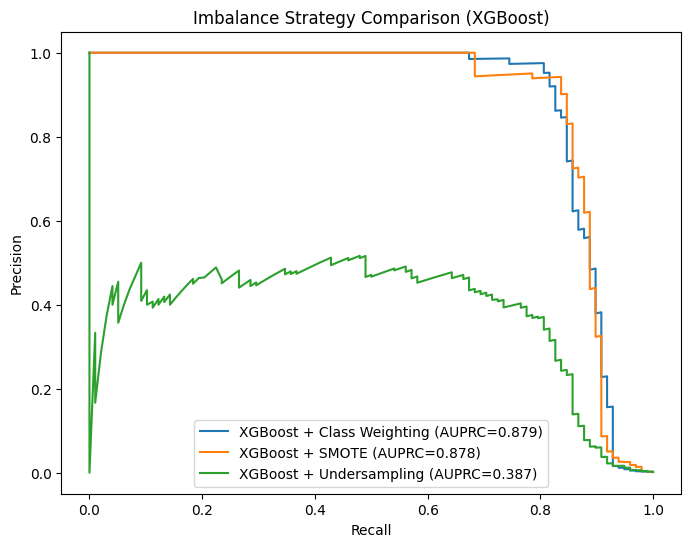

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))
for res in [results_weighted, results_smote, results_under]:
    precision, recall, _ = precision_recall_curve(y_test, res['y_proba'])
    plt.plot(recall, precision, label=f"{res['name']} (AUPRC={res['auprc']:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Imbalance Strategy Comparison (XGBoost)")
plt.legend()
plt.savefig("../outputs/03_imbalance_comparison.png", dpi=150, bbox_inches='tight')
plt.show()